In [ ]:
# ============================================
# 1. Environment Setup & Reproducibility
# ============================================

import os
import random
import numpy as np
import pandas as pd

# Fix seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ============================================
# 2. Load Dataset
# ============================================

# Set dataset path
DATA_PATH = "environmental analysis.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print(df.head())

# ============================================
# 3. Basic Data Cleaning
# ============================================

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# ============================================
# 4. Missing Value Handling
# ============================================

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Mean imputation for numerical
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Mode imputation for categorical
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ============================================
# 5. Data Type Formatting
# ============================================

# Convert categorical to string (safe casting)
for col in cat_cols:
    df[col] = df[col].astype(str)

# ============================================
# 6. Target Encoding
# ============================================

TARGET = "Environment Design"   # <-- confirm exact name

df[TARGET] = df[TARGET].map({
    "Green": 1,
    "Non-Green": 0
})

# ============================================
# 7. Categorical Encoding (Label Encoding)
# ============================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    if col != TARGET:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# ============================================
# 8. Outlier Handling (IQR-based Capping)
# ============================================

def iqr_capping(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)
    return df

for col in num_cols:
    df = iqr_capping(df, col)

# ============================================
# 9. Feature Scaling (Min-Max)
# ============================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_features = [col for col in num_cols if col != TARGET]

df[scaled_features] = scaler.fit_transform(df[scaled_features])

# ============================================
# 10. Data Leakage Audit
# ============================================

# Remove non-feature columns
if "building_id" in df.columns:
    df = df.drop(columns=["building_id"])

print("\nFinal Dataset Shape:", df.shape)

# ============================================
# 11. Feature Grouping
# ============================================

energy_features = [
    "energy_efficiency_score",
    "energy_consumption_sqft",
    "carbon_emission_tons",
    "hvac_type"
]

eco_tech_features = [
    "solar_panel_presence",
    "solar_installation",
    "rainwater_harvesting",
    "smart_systems"
]

design_features = [
    "facade_material",
    "roof_type",
    "green_roof",
    "window_wall_ratio",
    "insulation_type"
]

context_features = [
    "surrounding_green_space",
    "vegetation_presence",
    "year_built",
    "building_function"
]

# ============================================
# 12. PCA (Group-wise Dimensionality Reduction)
# ============================================

from sklearn.decomposition import PCA

def apply_pca(df, feature_list, n_components=0.95):
    pca = PCA(n_components=n_components, random_state=SEED)
    transformed = pca.fit_transform(df[feature_list])
    return transformed, pca

energy_pca, pca_energy = apply_pca(df, energy_features)
eco_pca, pca_eco = apply_pca(df, eco_tech_features)
design_pca, pca_design = apply_pca(df, design_features)
context_pca, pca_context = apply_pca(df, context_features)

print("\nPCA Shapes:")
print("Energy:", energy_pca.shape)
print("Eco-Tech:", eco_pca.shape)
print("Design:", design_pca.shape)
print("Context:", context_pca.shape)

# ============================================
# 13. Final Data Ready
# ============================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("\nFinal Features:", X.shape)
print("Target:", y.shape)

In [ ]:
# ============================================
# 1. Imports
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from pytorch_tabnet.tab_model import TabNetClassifier

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# 2. Helper: Metrics Function
# ============================================

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

# ============================================
# 3. Simple TabTransformer-like Model
# ============================================

class SimpleTabTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.attn = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.GELU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = x.unsqueeze(1)  # add sequence dim
        x, _ = self.attn(x, x, x)
        x = x.squeeze(1)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return torch.sigmoid(self.out(x))

# ============================================
# 4. SAINT (Simplified)
# ============================================

class SimpleSAINT(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.embed = nn.Linear(input_dim, 128)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=128, nhead=4, batch_first=True),
            num_layers=2
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embed(x).unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return torch.sigmoid(self.fc(x))

# ============================================
# 5. FT-Transformer (Approx)
# ============================================

class SimpleFTTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.GELU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return torch.sigmoid(self.out(x))

# ============================================
# 6. Training Function
# ============================================

def train_model(model, X_train, y_train, X_val, y_val, epochs=27):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)

    history = []

    for epoch in range(epochs):
        model.train()
        inputs = torch.tensor(X_train, dtype=torch.float32).to(device)
        labels = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
        probs = model(val_inputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

    return preds, probs, history

# ============================================
# 7. K-Fold Evaluation
# ============================================

def run_kfold(model_class, X, y, name):
    kf = KFold(n_splits=9, shuffle=True, random_state=42)

    metrics_all = []
    histories = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = model_class(X.shape[1])

        preds, probs, history = train_model(model, X_train.values, y_train, X_test.values, y_test)

        metrics = compute_metrics(y_test, preds, probs)
        metrics_all.append(metrics)
        histories.append(history)

    # Aggregate results
    results = {}
    for key in metrics_all[0].keys():
        vals = [m[key] for m in metrics_all]
        results[key] = (np.mean(vals)*100, np.std(vals)*100)

    return results, histories

# ============================================
# 8. TabNet Training
# ============================================

def run_tabnet(X, y):
    kf = KFold(n_splits=9, shuffle=True, random_state=42)

    metrics_all = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx].values, X.iloc[test_idx].values
        y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

        model = TabNetClassifier(seed=42, verbose=0)

        model.fit(X_train, y_train, max_epochs=27)

        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, preds, probs)
        metrics_all.append(metrics)

    results = {}
    for key in metrics_all[0].keys():
        vals = [m[key] for m in metrics_all]
        results[key] = (np.mean(vals)*100, np.std(vals)*100)

    return results

# ============================================
# 9. Run All Models
# ============================================

model_results = {}
model_histories = {}

# FT-Transformer
res_ft, hist_ft = run_kfold(SimpleFTTransformer, X, y, "FT-Transformer")
model_results["FT-Transformer"] = res_ft
model_histories["FT-Transformer"] = hist_ft

# SAINT
res_saint, hist_saint = run_kfold(SimpleSAINT, X, y, "SAINT")
model_results["SAINT"] = res_saint
model_histories["SAINT"] = hist_saint

# TabTransformer
res_tab, hist_tab = run_kfold(SimpleTabTransformer, X, y, "TabTransformer")
model_results["TabTransformer"] = res_tab
model_histories["TabTransformer"] = hist_tab

# TabNet
res_tabnet = run_tabnet(X, y)
model_results["TabNet"] = res_tabnet

# ============================================
# 10. Display Results
# ============================================

for model, metrics in model_results.items():
    print(f"\n{model}")
    for k, v in metrics.items():
        print(f"{k}: {v[0]:.2f} ± {v[1]:.2f}")

In [ ]:
# ============================================================
# TabFusionNet: Proposed Model + Ablations + K-Fold Evaluation
# ============================================================

import os
import copy
import json
import math
import random
import pickle
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 2. Paths
# ============================================================

OUTPUT_DIR = Path("tabfusionnet_outputs")
MODEL_DIR = OUTPUT_DIR / "saved_models"
HISTORY_DIR = OUTPUT_DIR / "histories"
RESULTS_DIR = OUTPUT_DIR / "results"

for p in [OUTPUT_DIR, MODEL_DIR, HISTORY_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ============================================================
# 3. Configuration
# ============================================================

CONFIG = {
    "embedding_dim": 64,
    "n_heads": 4,
    "n_transformer_layers": 2,
    "dropout": 0.3,
    "activation": "gelu",
    "batch_size": 64,
    "epochs": 27,
    "patience": 5,
    "learning_rate": 1e-4,
    "weight_decay": 0.01,
    "pca_variance": 0.95,
    "val_size_within_train": 0.1,
    "save_checkpoints": True
}

# ============================================================
# 4. Column Setup
#    Update these if your final column names differ
# ============================================================

TARGET_COL = "Environment Design"

FEATURE_GROUPS = {
    "Energy": [
        "energy_efficiency_score",
        "hvac_type",
        "energy_consumption_sqft",
        "carbon_emission_tons"
    ],
    "Eco-Tech": [
        "solar_panel_presence",
        "solar_installation",
        "green_roof",
        "rainwater_harvesting",
        "smart_systems"
    ],
    "Design": [
        "facade_material",
        "roof_type",
        "window_wall_ratio",
        "insulation_type"
    ],
    "Context": [
        "vegetation_presence",
        "surrounding_green_space",
        "green_certification",
        "year_built",
        "building_function"
    ]
}

# Optional identifier column that should never be used
ID_COLS = ["building_id"]

# ============================================================
# 5. Basic Metric Helpers
# ============================================================

def compute_metrics(y_true, y_prob, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

def summarize_metric_list(metric_list):
    summary = {}
    keys = metric_list[0].keys()
    for k in keys:
        vals = np.array([m[k] for m in metric_list], dtype=float)
        summary[k] = {
            "mean": vals.mean() * 100.0,
            "std": vals.std(ddof=1) * 100.0 if len(vals) > 1 else 0.0
        }
    return summary

# ============================================================
# 6. Group-wise PCA Fitting / Transform
# ============================================================

class GroupPCATransformer:
    """
    Fits PCA per feature group on train only, then transforms train/val/test.
    If use_pca=False, raw group features are passed through.
    """
    def __init__(self, feature_groups, variance_ratio=0.95, use_pca=True):
        self.feature_groups = feature_groups
        self.variance_ratio = variance_ratio
        self.use_pca = use_pca
        self.pca_models = {}
        self.output_dims = {}

    def fit(self, df_train: pd.DataFrame):
        for group_name, cols in self.feature_groups.items():
            Xg = df_train[cols].values.astype(np.float32)
            if self.use_pca:
                pca = PCA(n_components=self.variance_ratio, random_state=SEED)
                pca.fit(Xg)
                self.pca_models[group_name] = pca
                self.output_dims[group_name] = pca.transform(Xg).shape[1]
            else:
                self.pca_models[group_name] = None
                self.output_dims[group_name] = Xg.shape[1]
        return self

    def transform(self, df_part: pd.DataFrame):
        out = {}
        for group_name, cols in self.feature_groups.items():
            Xg = df_part[cols].values.astype(np.float32)
            if self.use_pca:
                out[group_name] = self.pca_models[group_name].transform(Xg).astype(np.float32)
            else:
                out[group_name] = Xg
        return out

# ============================================================
# 7. Dataset Wrapper
# ============================================================

class GroupTensorDataset(torch.utils.data.Dataset):
    def __init__(self, group_arrays: dict, y: np.ndarray):
        self.group_names = list(group_arrays.keys())
        self.group_arrays = group_arrays
        self.y = y.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = {g: torch.tensor(self.group_arrays[g][idx], dtype=torch.float32) for g in self.group_names}
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x, y

# ============================================================
# 8. Model Components
# ============================================================

class GroupEmbedding(nn.Module):
    def __init__(self, input_dims: dict, embedding_dim: int):
        super().__init__()
        self.group_layers = nn.ModuleDict({
            g: nn.Linear(dim, embedding_dim) for g, dim in input_dims.items()
        })

    def forward(self, group_inputs: dict):
        # returns [B, G, D]
        tokens = []
        for g in self.group_layers.keys():
            tokens.append(self.group_layers[g](group_inputs[g]).unsqueeze(1))
        return torch.cat(tokens, dim=1)

class FeedForwardBlock(nn.Module):
    def __init__(self, dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        return self.net(x)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, dropout: float):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = FeedForwardBlock(dim, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x, attn_weights

class HierarchicalTokenEncoder(nn.Module):
    def __init__(self, dim: int, n_heads: int, n_layers: int, dropout: float):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(dim, n_heads, dropout) for _ in range(n_layers)
        ])

    def forward(self, x):
        attn_maps = []
        for layer in self.layers:
            x, w = layer(x)
            attn_maps.append(w)
        return x, attn_maps

class FusionAttention(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, tokens):
        # tokens: [B, G, D]
        alpha = torch.softmax(self.score(tokens).squeeze(-1), dim=1)   # [B, G]
        fused = torch.sum(tokens * alpha.unsqueeze(-1), dim=1)         # [B, D]
        return fused, alpha

class AlignmentLayer(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.fc = nn.Linear(dim, dim)

    def forward(self, x):
        return self.fc(x)

class FlatFeatureTokenizer(nn.Module):
    """
    Used for ablation: no group-wise tokenization.
    All selected features are treated as flat features and projected as a single token.
    """
    def __init__(self, input_dim: int, embedding_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, embedding_dim)

    def forward(self, flat_x):
        token = self.fc(flat_x).unsqueeze(1)  # [B, 1, D]
        return token

# ============================================================
# 9. Proposed Model: TabFusionNet
# ============================================================

class TabFusionNet(nn.Module):
    def __init__(
        self,
        input_dims: dict,
        embedding_dim=64,
        n_heads=4,
        n_transformer_layers=2,
        dropout=0.3,
        use_fusion_attention=True,
        use_pca_alignment=True,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=True,
        flat_input_dim=None
    ):
        super().__init__()

        self.use_fusion_attention = use_fusion_attention
        self.use_pca_alignment = use_pca_alignment
        self.use_hierarchical_attention = use_hierarchical_attention
        self.use_groupwise_tokenization = use_groupwise_tokenization
        self.embedding_dim = embedding_dim

        if self.use_groupwise_tokenization:
            self.embedding = GroupEmbedding(input_dims, embedding_dim)
            self.n_tokens = len(input_dims)
        else:
            assert flat_input_dim is not None, "flat_input_dim must be provided when group-wise tokenization is disabled."
            self.flat_tokenizer = FlatFeatureTokenizer(flat_input_dim, embedding_dim)
            self.n_tokens = 1

        if self.use_hierarchical_attention:
            self.encoder = HierarchicalTokenEncoder(
                dim=embedding_dim,
                n_heads=n_heads,
                n_layers=n_transformer_layers,
                dropout=dropout
            )
        else:
            self.encoder = None

        if self.use_fusion_attention:
            self.fusion = FusionAttention(embedding_dim)
        else:
            self.fusion = None

        self.alignment = AlignmentLayer(embedding_dim)

        # To match your Table 6 notion: classifier head 128 -> 64 -> output
        self.fc1 = nn.Linear(embedding_dim * 2, 64)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, group_inputs=None, flat_inputs=None):
        aux = {}

        if self.use_groupwise_tokenization:
            tokens = self.embedding(group_inputs)   # [B, G, 64]
        else:
            tokens = self.flat_tokenizer(flat_inputs)  # [B, 1, 64]

        aux["tokens_in"] = tokens

        if self.use_hierarchical_attention:
            tokens, attn_maps = self.encoder(tokens)
            aux["attn_maps"] = attn_maps
        else:
            aux["attn_maps"] = None

        aux["tokens_out"] = tokens

        if self.use_fusion_attention:
            fused, alpha = self.fusion(tokens)  # [B, 64]
            aux["fusion_weights"] = alpha
        else:
            fused = tokens.mean(dim=1)
            aux["fusion_weights"] = None

        aligned = self.alignment(fused)  # [B, 64]
        aux["aligned"] = aligned

        combined = torch.cat([fused, aligned], dim=1)  # [B, 128]
        x = self.drop(self.act(self.fc1(combined)))
        logits = self.fc2(x).squeeze(1)
        aux["logits"] = logits

        return logits, aux

# ============================================================
# 10. Training Helpers
# ============================================================

def build_dataloaders(train_groups, y_train, val_groups, y_val, batch_size=64):
    train_ds = GroupTensorDataset(train_groups, y_train)
    val_ds = GroupTensorDataset(val_groups, y_val)

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, drop_last=False
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, drop_last=False
    )
    return train_loader, val_loader

def build_flat_arrays(df_part: pd.DataFrame, feature_groups: dict):
    cols = []
    for _, group_cols in feature_groups.items():
        cols.extend(group_cols)
    return df_part[cols].values.astype(np.float32)

def train_one_fold(
    model,
    train_loader,
    val_loader,
    y_train_np,
    model_name,
    fold_id,
    save_dir,
    lr=1e-4,
    weight_decay=0.01,
    epochs=27,
    patience=5,
    use_groupwise_tokenization=True,
    flat_train=None,
    flat_val=None
):
    pos_count = np.sum(y_train_np == 1)
    neg_count = np.sum(y_train_np == 0)
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.to(DEVICE)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": []
    }

    best_state = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_y = batch_y.to(DEVICE)

            if use_groupwise_tokenization:
                batch_x = {k: v.to(DEVICE) for k, v in batch_x.items()}
                logits, _ = model(group_inputs=batch_x)
            else:
                raise ValueError("This trainer expects grouped inputs. Use flat trainer separately if needed.")

            loss = criterion(logits, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_y.size(0)

        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_running_loss = 0.0
        all_probs = []
        all_true = []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_y = batch_y.to(DEVICE)

                if use_groupwise_tokenization:
                    batch_x = {k: v.to(DEVICE) for k, v in batch_x.items()}
                    logits, _ = model(group_inputs=batch_x)
                else:
                    raise ValueError("This trainer expects grouped inputs. Use flat trainer separately if needed.")

                loss = criterion(logits, batch_y)
                val_running_loss += loss.item() * batch_y.size(0)

                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.extend(probs)
                all_true.extend(batch_y.cpu().numpy())

        val_loss = val_running_loss / len(val_loader.dataset)
        metrics = compute_metrics(np.array(all_true), np.array(all_probs))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(metrics["accuracy"] * 100)
        history["val_precision"].append(metrics["precision"] * 100)
        history["val_recall"].append(metrics["recall"] * 100)
        history["val_f1"].append(metrics["f1_score"] * 100)
        history["val_roc_auc"].append(metrics["roc_auc"] * 100)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0

            if CONFIG["save_checkpoints"]:
                torch.save(
                    best_state,
                    save_dir / f"{model_name}_fold{fold_id}_best.pt"
                )
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

def evaluate_model(model, test_groups, y_test, use_groupwise_tokenization=True, flat_test=None):
    model.eval()
    probs_all = []

    with torch.no_grad():
        if use_groupwise_tokenization:
            ds = GroupTensorDataset(test_groups, y_test)
            loader = torch.utils.data.DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False)
            for batch_x, _ in loader:
                batch_x = {k: v.to(DEVICE) for k, v in batch_x.items()}
                logits, _ = model(group_inputs=batch_x)
                probs = torch.sigmoid(logits).cpu().numpy()
                probs_all.extend(probs)
        else:
            x_tensor = torch.tensor(flat_test, dtype=torch.float32).to(DEVICE)
            logits, _ = model(flat_inputs=x_tensor)
            probs_all = torch.sigmoid(logits).cpu().numpy()

    return compute_metrics(y_test, np.array(probs_all)), np.array(probs_all)

# ============================================================
# 11. Main K-Fold Runner for Proposed Model / Ablations
# ============================================================

def run_tabfusion_kfold(
    df: pd.DataFrame,
    feature_groups: dict,
    target_col: str,
    n_splits: int,
    variant_name: str,
    use_pca=True,
    use_fusion_attention=True,
    use_hierarchical_attention=True,
    use_groupwise_tokenization=True,
    save_models=True
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    fold_metrics = []
    fold_histories = []
    fold_models = []
    epoch_val_acc = []

    X_df = df.drop(columns=[target_col] + [c for c in ID_COLS if c in df.columns], errors="ignore").copy()
    y = df[target_col].values.astype(int)

    for fold_id, (train_idx, test_idx) in enumerate(skf.split(X_df, y), start=1):
        df_train_full = df.iloc[train_idx].reset_index(drop=True)
        df_test = df.iloc[test_idx].reset_index(drop=True)

        df_train, df_val = train_test_split(
            df_train_full,
            test_size=CONFIG["val_size_within_train"],
            stratify=df_train_full[target_col],
            random_state=SEED
        )

        # Group-wise PCA fit on train only
        pca_transformer = GroupPCATransformer(
            feature_groups=feature_groups,
            variance_ratio=CONFIG["pca_variance"],
            use_pca=use_pca
        ).fit(df_train)

        train_groups = pca_transformer.transform(df_train)
        val_groups = pca_transformer.transform(df_val)
        test_groups = pca_transformer.transform(df_test)

        input_dims = {g: arr.shape[1] for g, arr in train_groups.items()}

        if use_groupwise_tokenization:
            model = TabFusionNet(
                input_dims=input_dims,
                embedding_dim=CONFIG["embedding_dim"],
                n_heads=CONFIG["n_heads"],
                n_transformer_layers=CONFIG["n_transformer_layers"],
                dropout=CONFIG["dropout"],
                use_fusion_attention=use_fusion_attention,
                use_pca_alignment=use_pca,
                use_hierarchical_attention=use_hierarchical_attention,
                use_groupwise_tokenization=True
            )
            train_loader, val_loader = build_dataloaders(
                train_groups, df_train[target_col].values,
                val_groups, df_val[target_col].values,
                batch_size=CONFIG["batch_size"]
            )

            model, history = train_one_fold(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                y_train_np=df_train[target_col].values,
                model_name=variant_name,
                fold_id=fold_id,
                save_dir=MODEL_DIR,
                lr=CONFIG["learning_rate"],
                weight_decay=CONFIG["weight_decay"],
                epochs=CONFIG["epochs"],
                patience=CONFIG["patience"],
                use_groupwise_tokenization=True
            )

            metrics, probs = evaluate_model(
                model=model,
                test_groups=test_groups,
                y_test=df_test[target_col].values,
                use_groupwise_tokenization=True
            )

        else:
            # Flat-tokenization ablation
            flat_train = build_flat_arrays(df_train, feature_groups)
            flat_val = build_flat_arrays(df_val, feature_groups)
            flat_test = build_flat_arrays(df_test, feature_groups)

            class FlatWrapper(nn.Module):
                def __init__(self, flat_dim):
                    super().__init__()
                    self.core = TabFusionNet(
                        input_dims={},
                        embedding_dim=CONFIG["embedding_dim"],
                        n_heads=CONFIG["n_heads"],
                        n_transformer_layers=CONFIG["n_transformer_layers"],
                        dropout=CONFIG["dropout"],
                        use_fusion_attention=use_fusion_attention,
                        use_pca_alignment=use_pca,
                        use_hierarchical_attention=use_hierarchical_attention,
                        use_groupwise_tokenization=False,
                        flat_input_dim=flat_dim
                    )

                def forward(self, x):
                    return self.core(flat_inputs=x)

            model = FlatWrapper(flat_train.shape[1]).to(DEVICE)

            pos_count = np.sum(df_train[target_col].values == 1)
            neg_count = np.sum(df_train[target_col].values == 0)
            pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32).to(DEVICE)

            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

            history = {
                "train_loss": [],
                "val_loss": [],
                "val_accuracy": [],
                "val_precision": [],
                "val_recall": [],
                "val_f1": [],
                "val_roc_auc": []
            }

            Xtr = torch.tensor(flat_train, dtype=torch.float32).to(DEVICE)
            ytr = torch.tensor(df_train[target_col].values, dtype=torch.float32).to(DEVICE)
            Xv = torch.tensor(flat_val, dtype=torch.float32).to(DEVICE)
            yv = torch.tensor(df_val[target_col].values, dtype=torch.float32).to(DEVICE)

            best_state = None
            best_val_loss = float("inf")
            wait = 0

            for epoch in range(CONFIG["epochs"]):
                model.train()
                logits, _ = model(Xtr)
                loss = criterion(logits, ytr)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()

                model.eval()
                with torch.no_grad():
                    val_logits, _ = model(Xv)
                    val_loss = criterion(val_logits, yv)

                    val_probs = torch.sigmoid(val_logits).cpu().numpy()
                    metrics_val = compute_metrics(df_val[target_col].values, val_probs)

                history["train_loss"].append(loss.item())
                history["val_loss"].append(val_loss.item())
                history["val_accuracy"].append(metrics_val["accuracy"] * 100)
                history["val_precision"].append(metrics_val["precision"] * 100)
                history["val_recall"].append(metrics_val["recall"] * 100)
                history["val_f1"].append(metrics_val["f1_score"] * 100)
                history["val_roc_auc"].append(metrics_val["roc_auc"] * 100)

                if val_loss.item() < best_val_loss:
                    best_val_loss = val_loss.item()
                    best_state = copy.deepcopy(model.state_dict())
                    wait = 0
                    if CONFIG["save_checkpoints"]:
                        torch.save(best_state, MODEL_DIR / f"{variant_name}_fold{fold_id}_best.pt")
                else:
                    wait += 1
                    if wait >= CONFIG["patience"]:
                        break

            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                Xt = torch.tensor(flat_test, dtype=torch.float32).to(DEVICE)
                test_logits, _ = model(Xt)
                test_probs = torch.sigmoid(test_logits).cpu().numpy()
                metrics = compute_metrics(df_test[target_col].values, test_probs)

        fold_metrics.append(metrics)
        fold_histories.append(history)
        fold_models.append(model.state_dict())

        epoch_val_acc.append(history["val_accuracy"])

        # Save fold history
        with open(HISTORY_DIR / f"{variant_name}_fold{fold_id}_history.pkl", "wb") as f:
            pickle.dump(history, f)

    summary = summarize_metric_list(fold_metrics)

    # Epoch-wise mean/std for validation accuracy across folds
    max_len = max(len(h) for h in epoch_val_acc)
    padded = np.full((len(epoch_val_acc), max_len), np.nan, dtype=float)
    for i, arr in enumerate(epoch_val_acc):
        padded[i, :len(arr)] = arr
    epoch_mean = np.nanmean(padded, axis=0)
    epoch_std = np.nanstd(padded, axis=0, ddof=1)

    epoch_summary = {
        "epoch": list(range(1, len(epoch_mean) + 1)),
        "val_accuracy_mean": epoch_mean.tolist(),
        "val_accuracy_std": epoch_std.tolist()
    }

    # Save summary
    with open(RESULTS_DIR / f"{variant_name}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    with open(RESULTS_DIR / f"{variant_name}_epoch_summary.json", "w") as f:
        json.dump(epoch_summary, f, indent=2)

    return {
        "variant_name": variant_name,
        "fold_metrics": fold_metrics,
        "summary": summary,
        "fold_histories": fold_histories,
        "fold_models": fold_models,
        "epoch_summary": epoch_summary
    }

# ============================================================
# 12. Utility: Print Summary Nicely
# ============================================================

def print_summary(result_dict):
    print(f"\n=== {result_dict['variant_name']} ===")
    for metric, vals in result_dict["summary"].items():
        print(f"{metric}: {vals['mean']:.2f} ± {vals['std']:.2f}")

# ============================================================
# 13. Proposed Full Model
# ============================================================

def run_full_proposed_model(df):
    return run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="TabFusionNet_FullModel",
        use_pca=True,
        use_fusion_attention=True,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=True
    )

# ============================================================
# 14. Feature Group Ablation
# ============================================================

def run_feature_group_ablation(df):
    results = {}

    for group_name, group_cols in FEATURE_GROUPS.items():
        sub_groups = {group_name: group_cols}
        result = run_tabfusion_kfold(
            df=df,
            feature_groups=sub_groups,
            target_col=TARGET_COL,
            n_splits=9,
            variant_name=f"Ablation_Group_{group_name}",
            use_pca=True,
            use_fusion_attention=True,
            use_hierarchical_attention=True,
            use_groupwise_tokenization=True
        )
        results[group_name] = result
        print_summary(result)

    return results

# ============================================================
# 15. Feature Fusion Combination Analysis
# ============================================================

def run_feature_fusion_combinations(df):
    results = {}

    group_names = list(FEATURE_GROUPS.keys())

    # all 2-group and 3-group combinations
    combo_list = list(combinations(group_names, 2)) + list(combinations(group_names, 3))

    for combo in combo_list:
        sub_groups = {g: FEATURE_GROUPS[g] for g in combo}
        variant_name = "Fusion_" + "_".join(combo)

        result = run_tabfusion_kfold(
            df=df,
            feature_groups=sub_groups,
            target_col=TARGET_COL,
            n_splits=9,
            variant_name=variant_name,
            use_pca=True,
            use_fusion_attention=True,
            use_hierarchical_attention=True,
            use_groupwise_tokenization=True
        )
        results[combo] = result
        print_summary(result)

    return results

# ============================================================
# 16. Architectural Component Ablation
# ============================================================

def run_architectural_ablation(df):
    results = {}

    # Full model
    results["FullModel"] = run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="ArchAblation_FullModel",
        use_pca=True,
        use_fusion_attention=True,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=True
    )
    print_summary(results["FullModel"])

    # Remove Fusion Attention
    results["No_FusionAttention"] = run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="ArchAblation_NoFusionAttention",
        use_pca=True,
        use_fusion_attention=False,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=True
    )
    print_summary(results["No_FusionAttention"])

    # Remove PCA Alignment
    results["No_PCAAlignment"] = run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="ArchAblation_NoPCAAlignment",
        use_pca=False,
        use_fusion_attention=True,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=True
    )
    print_summary(results["No_PCAAlignment"])

    # Remove Hierarchical Attention
    results["No_HierarchicalAttention"] = run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="ArchAblation_NoHierarchicalAttention",
        use_pca=True,
        use_fusion_attention=True,
        use_hierarchical_attention=False,
        use_groupwise_tokenization=True
    )
    print_summary(results["No_HierarchicalAttention"])

    # Remove Group-wise Tokenization (flat features)
    results["Flat_Features"] = run_tabfusion_kfold(
        df=df,
        feature_groups=FEATURE_GROUPS,
        target_col=TARGET_COL,
        n_splits=9,
        variant_name="ArchAblation_FlatFeatures",
        use_pca=True,
        use_fusion_attention=True,
        use_hierarchical_attention=True,
        use_groupwise_tokenization=False
    )
    print_summary(results["Flat_Features"])

    return results

# ============================================================
# 17. K-Fold Cross-Validation Across K = 3, 5, 7, 9
# ============================================================

def run_kfold_sensitivity(df, k_values=(3, 5, 7, 9)):
    results = {}

    for k in k_values:
        result = run_tabfusion_kfold(
            df=df,
            feature_groups=FEATURE_GROUPS,
            target_col=TARGET_COL,
            n_splits=k,
            variant_name=f"KFold_{k}",
            use_pca=True,
            use_fusion_attention=True,
            use_hierarchical_attention=True,
            use_groupwise_tokenization=True
        )
        results[k] = result
        print_summary(result)

    return results

# ============================================================
# 18. Result Table Builders
# ============================================================

def build_metrics_dataframe(result_map, label_key="Model Variant"):
    rows = []
    for name, res in result_map.items():
        s = res["summary"]
        rows.append({
            label_key: str(name),
            "Accuracy": f"{s['accuracy']['mean']:.1f} ± {s['accuracy']['std']:.1f}",
            "Precision": f"{s['precision']['mean']:.1f} ± {s['precision']['std']:.1f}",
            "Recall": f"{s['recall']['mean']:.1f} ± {s['recall']['std']:.1f}",
            "F1-Score": f"{s['f1_score']['mean']:.1f} ± {s['f1_score']['std']:.1f}",
            "ROC-AUC": f"{s['roc_auc']['mean']:.1f} ± {s['roc_auc']['std']:.1f}",
        })
    return pd.DataFrame(rows)

def build_epoch_accuracy_df(kfold_results):
    rows = []
    for k, res in kfold_results.items():
        epoch_summary = res["epoch_summary"]
        for ep, mean_acc, std_acc in zip(
            epoch_summary["epoch"],
            epoch_summary["val_accuracy_mean"],
            epoch_summary["val_accuracy_std"]
        ):
            rows.append({
                "Epoch": ep,
                "K": k,
                "Validation Accuracy Mean": mean_acc,
                "Validation Accuracy Std": std_acc,
                "Validation Accuracy (mean ± std)": f"{mean_acc:.1f} ± {std_acc:.1f}"
            })
    return pd.DataFrame(rows)

# ============================================================
# 19. Run Everything
#    Assumes a preprocessed df is already available
# ============================================================

# Example:
# df = pd.read_csv("your_preprocessed_dataset.csv")

# Make sure ID column is not used
for col in ID_COLS:
    if col in df.columns:
        print(f"Dropping ID column from modeling: {col}")

# Full proposed model
proposed_full_result = run_full_proposed_model(df)
print_summary(proposed_full_result)

# Feature group ablation
feature_group_ablation_results = run_feature_group_ablation(df)

# Feature fusion combinations
feature_fusion_results = run_feature_fusion_combinations(df)

# Architectural component ablation
architectural_ablation_results = run_architectural_ablation(df)

# K-fold sensitivity: k3, k5, k7, k9
kfold_sensitivity_results = run_kfold_sensitivity(df, k_values=(3, 5, 7, 9))

# ============================================================
# 20. Build DataFrames for Tables
# ============================================================

# Table: Feature Group Ablation
df_feature_group_ablation = build_metrics_dataframe(feature_group_ablation_results)
df_feature_group_ablation.to_csv(RESULTS_DIR / "feature_group_ablation.csv", index=False)

# Table: Feature Fusion Combinations
df_feature_fusion = build_metrics_dataframe(feature_fusion_results)
df_feature_fusion.to_csv(RESULTS_DIR / "feature_fusion_combinations.csv", index=False)

# Table: Architectural Component Ablation
df_architectural_ablation = build_metrics_dataframe(architectural_ablation_results)
df_architectural_ablation.to_csv(RESULTS_DIR / "architectural_component_ablation.csv", index=False)

# Table: K-fold epoch-wise accuracy
df_kfold_epochs = build_epoch_accuracy_df(kfold_sensitivity_results)
df_kfold_epochs.to_csv(RESULTS_DIR / "kfold_epoch_accuracy.csv", index=False)

# Save proposed full model summary
with open(RESULTS_DIR / "proposed_full_result.pkl", "wb") as f:
    pickle.dump(proposed_full_result, f)

with open(RESULTS_DIR / "feature_group_ablation_results.pkl", "wb") as f:
    pickle.dump(feature_group_ablation_results, f)

with open(RESULTS_DIR / "feature_fusion_results.pkl", "wb") as f:
    pickle.dump(feature_fusion_results, f)

with open(RESULTS_DIR / "architectural_ablation_results.pkl", "wb") as f:
    pickle.dump(architectural_ablation_results, f)

with open(RESULTS_DIR / "kfold_sensitivity_results.pkl", "wb") as f:
    pickle.dump(kfold_sensitivity_results, f)

print("\nSaved outputs to:", OUTPUT_DIR)

# ============================================================
# 21. Easy Access Variables Later
# ============================================================

# Main proposed result
TABFUSIONNET_RESULT = proposed_full_result

# Histories
TABFUSIONNET_HISTORIES = proposed_full_result["fold_histories"]

# Summaries
TABFUSIONNET_SUMMARY = proposed_full_result["summary"]

# Ablations
FEATURE_GROUP_ABLATION = feature_group_ablation_results
FEATURE_FUSION_ABLATION = feature_fusion_results
ARCH_COMPONENT_ABLATION = architectural_ablation_results

# K-fold sensitivity
KFOLD_RESULTS = kfold_sensitivity_results

print("\nQuick access variables created:")
print("TABFUSIONNET_RESULT")
print("TABFUSIONNET_HISTORIES")
print("TABFUSIONNET_SUMMARY")
print("FEATURE_GROUP_ABLATION")
print("FEATURE_FUSION_ABLATION")
print("ARCH_COMPONENT_ABLATION")
print("KFOLD_RESULTS")

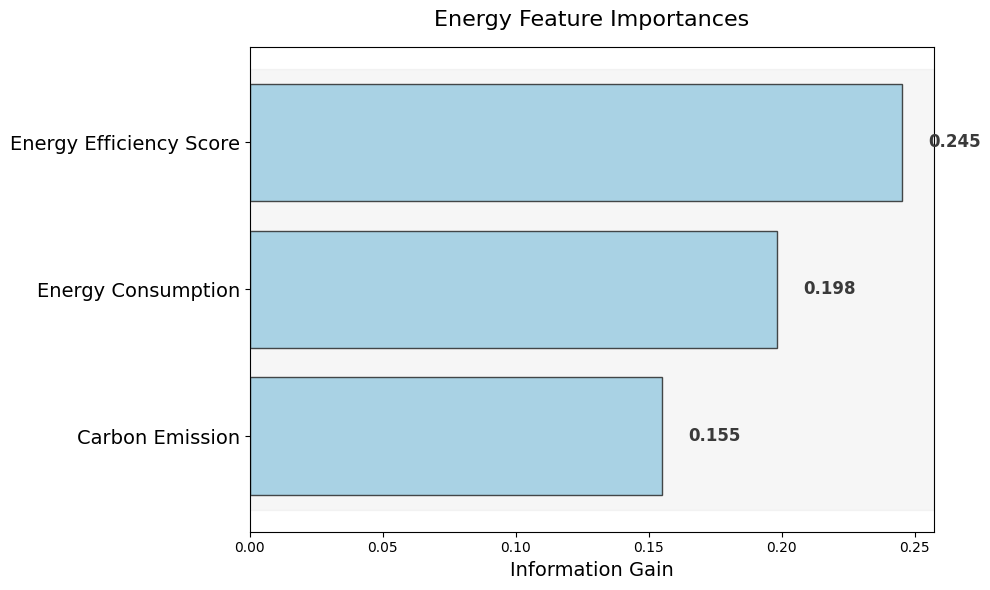

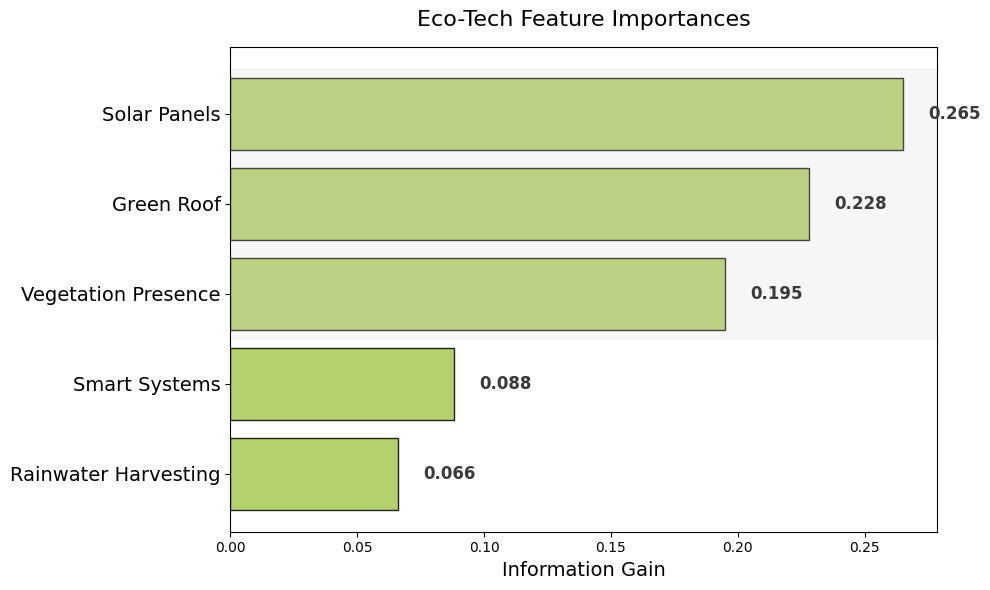

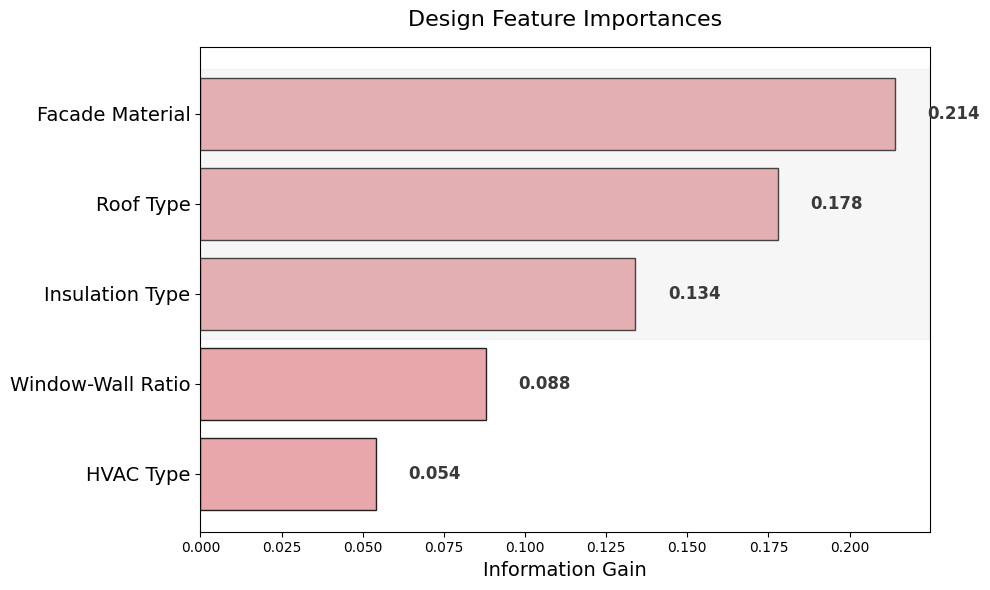

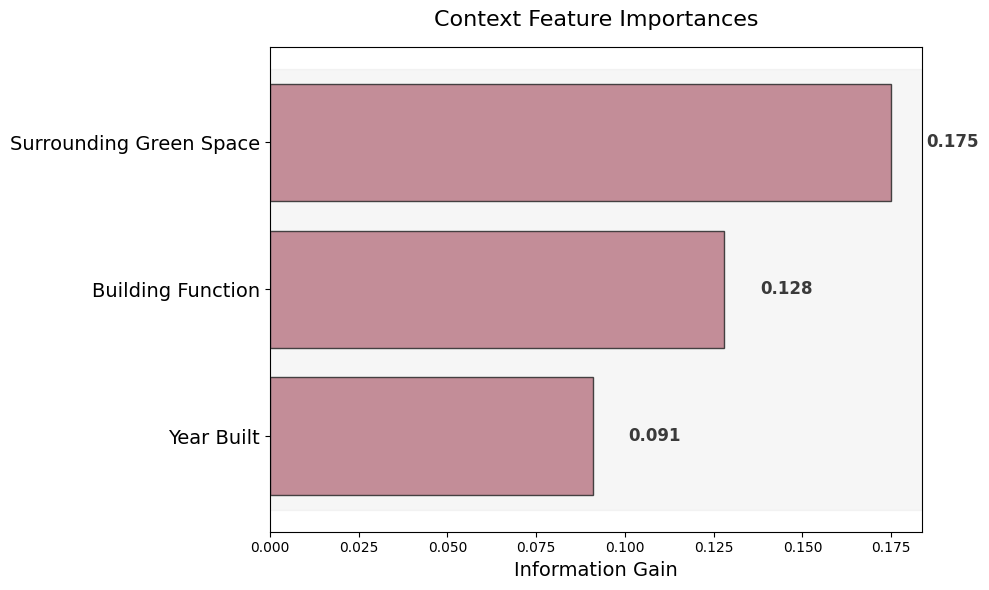

In [ ]:

# ============================================================
# 23. Compute Information Gain
# ============================================================

def compute_information_gain(df, features, target):
    X = df[features].values
    y = df[target].values

    mi = mutual_info_classif(X, y, random_state=42)

    return dict(zip(features, mi))

# Compute for all groups
info_gain_results = {}

for group, features in FEATURE_GROUPS.items():
    info_gain_results[group] = compute_information_gain(df, features, TARGET)

# ============================================================
# 4. Plot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

group_order = ["Context", "Energy", "Eco-Tech", "Design"]
colors = {
    "Context": "#b07d82",   # muted red
    "Energy": "#8fb3c7",    # blue
    "Eco-Tech": "#a9c273",  # green
    "Design": "#d09a9a"     # pink
}

subplot_labels = ["a)", "b)", "c)", "d)"]

for idx, (group, ax) in enumerate(zip(group_order, axes.flatten())):

    data = info_gain_results[group]

    # Sort features by importance
    features = list(data.keys())
    values = list(data.values())

    sorted_idx = np.argsort(values)
    features = [features[i] for i in sorted_idx]
    values = [values[i] for i in sorted_idx]

    ax.barh(features, values, color=colors[group])

    # Add value labels
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)

    ax.set_xlabel("Information Gain")
    ax.set_title(group)

    # Subplot label (a, b, c, d)
    ax.text(0.5, -0.25, subplot_labels[idx],
            transform=ax.transAxes,
            fontsize=14, ha='center')

plt.tight_layout()
plt.show()

                Accuracy  Precision  Recall    F1   AUC
FT-Transformer      73.0       80.1    74.2  72.8  73.5
SAINT               82.0       87.4    82.8  81.6  82.2
TabNet              84.0       89.2    84.6  83.7  84.1
TabTransformer      88.6       93.1    88.9  88.2  88.5
Proposed            97.5       97.6    97.4  97.5  99.8


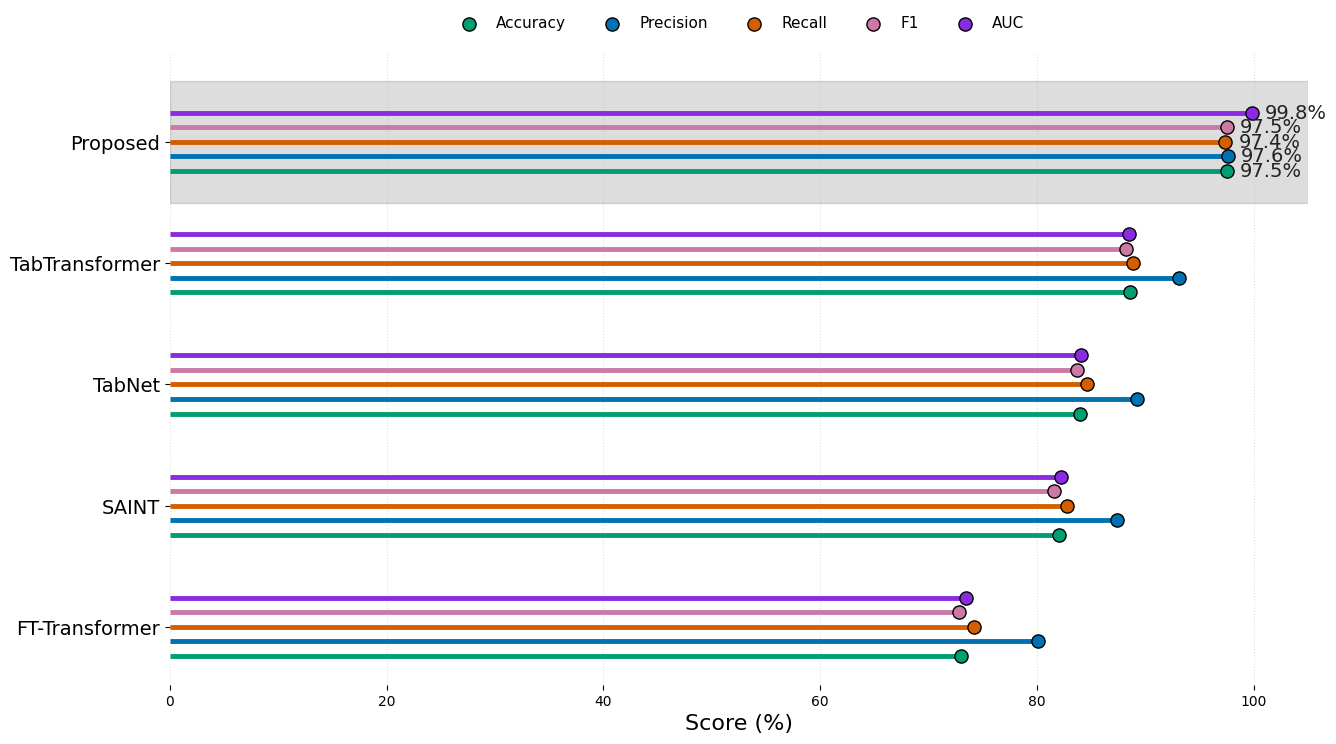

In [ ]:


import os
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load saved results
#    A) in-memory variables already created
#    B) saved pickle/json files
# ============================================================

USE_SAVED_FILES = False   # set True if loading from disk

if not USE_SAVED_FILES:
    #  in-memory variables from previous code
    # baseline
    # model_results
    # proposed
    # TABFUSIONNET_SUMMARY or TABFUSIONNET_RESULT
    baseline_results = model_results

    proposed_summary = TABFUSIONNET_SUMMARY
else:
    # -------- baseline: load from your saved object --------
    with open("tabfusionnet_outputs/results/baseline_model_results.pkl", "rb") as f:
        baseline_results = pickle.load(f)

    # -------- proposed: load summary --------
    with open("tabfusionnet_outputs/results/proposed_full_result.pkl", "rb") as f:
        proposed_full = pickle.load(f)
    proposed_summary = proposed_full["summary"]

# ============================================================
# 2. Standardize metrics into one dict
# ============================================================

def normalize_summary_dict(result_entry):
    """
    Converts either:
    {'accuracy': (mean, std), ...}
    OR
    {'accuracy': {'mean': x, 'std': y}, ...}
    into:
    {'Accuracy': mean, 'Precision': mean, ...}
    """
    out = {}

    mapping = {
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "f1_score": "F1",
        "roc_auc": "AUC",
        "auc": "AUC"
    }

    for k, v in result_entry.items():
        lk = k.lower()
        if lk not in mapping:
            continue

        new_k = mapping[lk]

        if isinstance(v, dict) and "mean" in v:
            out[new_k] = float(v["mean"])
        elif isinstance(v, (tuple, list, np.ndarray)):
            out[new_k] = float(v[0])
        else:
            out[new_k] = float(v)

    return out

plot_results = {}

# baseline models
for model_name, res in baseline_results.items():
    plot_results[model_name] = normalize_summary_dict(res)

# proposed model
plot_results["Proposed"] = normalize_summary_dict(proposed_summary)

# ============================================================
# 3. Ensure ordering
# ============================================================

model_order = ["FT-Transformer", "SAINT", "TabNet", "TabTransformer", "Proposed"]

# handle your baseline key naming if different
resolved_order = []
for name in model_order:
    if name in plot_results:
        resolved_order.append(name)
    elif name == "TabTransformer" and "TabTransformer (Simple)" in plot_results:
        resolved_order.append("TabTransformer (Simple)")

metrics_order = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

# ============================================================
# 4. Colors
# ============================================================

metric_colors = {
    "Accuracy": "#1abc9c",   # teal-green
    "Precision": "#1f77b4",  # blue
    "Recall": "#e67e22",     # orange
    "F1": "#cc79a7",         # pink
    "AUC": "#8a2be2"         # purple
}

# ============================================================
# 5. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

y_base = np.arange(len(resolved_order))
offsets = np.linspace(-0.24, 0.24, len(metrics_order))

for m_idx, metric in enumerate(metrics_order):
    ys = y_base + offsets[m_idx]

    for i, model_name in enumerate(resolved_order):
        score = plot_results[model_name][metric]

        # horizontal line from 0 to score
        ax.hlines(
            y=ys[i],
            xmin=0,
            xmax=score,
            color=metric_colors[metric],
            linewidth=2.5
        )

        # endpoint marker
        ax.scatter(
            score,
            ys[i],
            s=55,
            color=metric_colors[metric],
            edgecolor="black",
            linewidth=0.8,
            zorder=3
        )

        # annotate only for Proposed
        if model_name == "Proposed":
            ax.text(
                score + 1.0,
                ys[i],
                f"{score:.1f}%",
                va="center",
                ha="left",
                fontsize=11
            )

# ============================================================
# 6. Axes styling
# ============================================================

ax.set_yticks(y_base)
ax.set_yticklabels(resolved_order, fontsize=13)
ax.set_xlabel("Score (%)", fontsize=14)

ax.set_xlim(0, 105)
ax.grid(axis="x", linestyle="--", alpha=0.3)

# clean frame
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', length=0)

# ============================================================
# 7. Legend at top center
# ============================================================

legend_handles = []
for metric in metrics_order:
    handle = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=7,
        markerfacecolor=metric_colors[metric],
        markeredgecolor='black',
        markeredgewidth=0.8,
        label=metric
    )
    legend_handles.append(handle)

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.4
)

plt.tight_layout()

# ============================================================
# 8. Save figure
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

png_path = os.path.join(save_dir, "baseline_vs_proposed_metric_comparison.png")
pdf_path = os.path.join(save_dir, "baseline_vs_proposed_metric_comparison.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

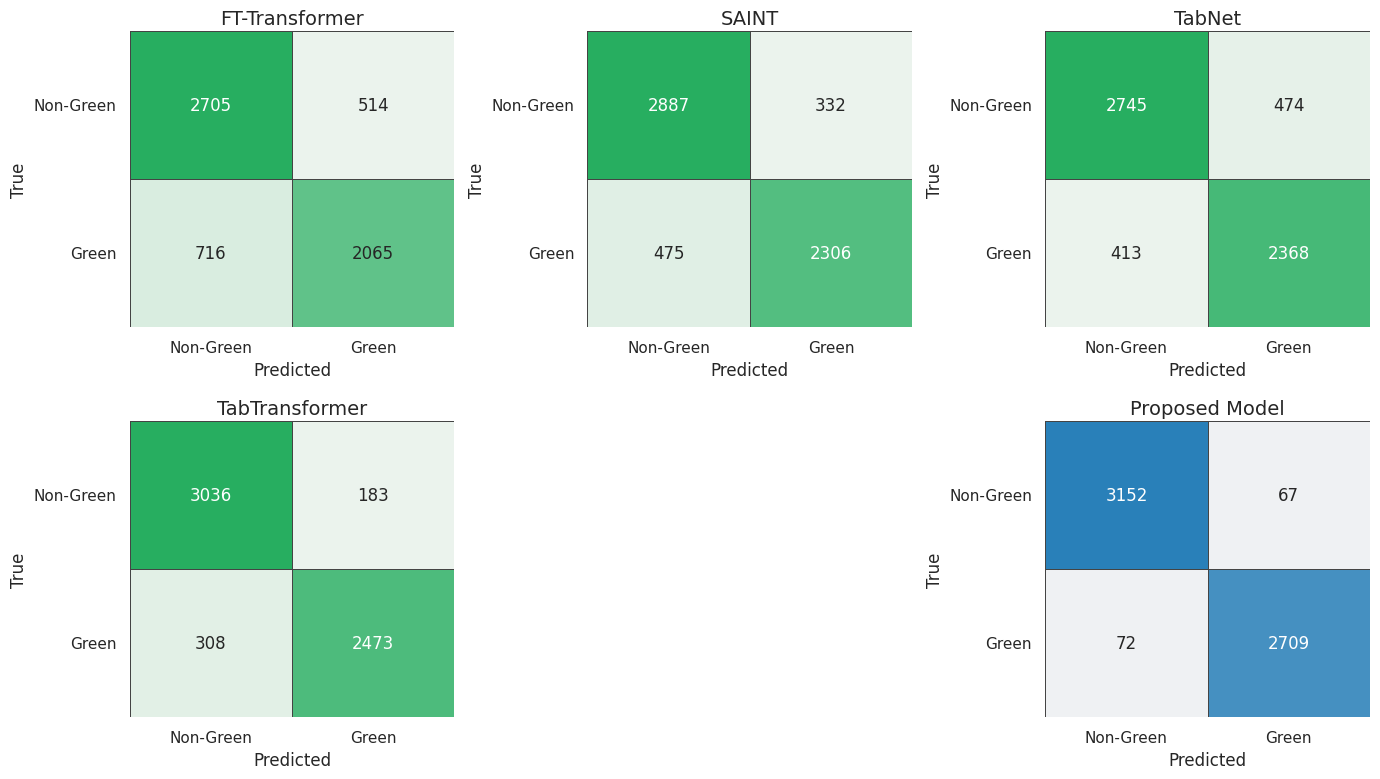

In [ ]:


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# 1. Load Predictions (from saved history or variables)
# ============================================================

USE_SAVED = False

if USE_SAVED:
    import pickle

    predictions = {}

    model_names = ["FT-Transformer", "SAINT", "TabNet", "TabTransformer", "Proposed"]

    for name in model_names:
        path = f"tabfusionnet_outputs/predictions/{name}_pred.pkl"
        with open(path, "rb") as f:
            predictions[name] = pickle.load(f)

# ============================================================
# 2. Ensure Predictions Exist
# ============================================================

# Example fallback (if not already stored)
# Replace with your actual prediction pipeline

if "predictions" not in globals():
    raise ValueError("Please provide predictions dictionary or load saved predictions.")

# ============================================================
# 3. Plot Configuration
# ============================================================

model_order = ["FT-Transformer", "SAINT", "TabNet", "TabTransformer", "Proposed"]

# Colors
cmap_baseline = sns.light_palette("#2ecc71", as_cmap=True)  # green
cmap_proposed = sns.light_palette("#2980b9", as_cmap=True)  # blue

# ============================================================
# 4. Create Figure Layout (2x3 grid)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes = axes.flatten()

for idx, model_name in enumerate(model_order):

    ax = axes[idx]

    y_true, y_pred = predictions[model_name]

    cm = confusion_matrix(y_true, y_pred)

    # Choose color map
    cmap = cmap_proposed if model_name == "Proposed" else cmap_baseline

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        cbar=False,
        ax=ax,
        annot_kws={"size": 10, "weight": "bold"},
        linewidths=0.5,
        linecolor="black"
    )

    # Labels
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)

    ax.set_xticklabels(["Non-Green", "Green"], fontsize=9)
    ax.set_yticklabels(["Non-Green", "Green"], fontsize=9, rotation=0)

# Hide last subplot (empty)
axes[-1].axis("off")

plt.tight_layout()

# ============================================================
# 5. Save Figure
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/confusion_matrix_all_models.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/confusion_matrix_all_models.pdf", bbox_inches="tight")

plt.show()

print("Confusion matrices saved successfully.")

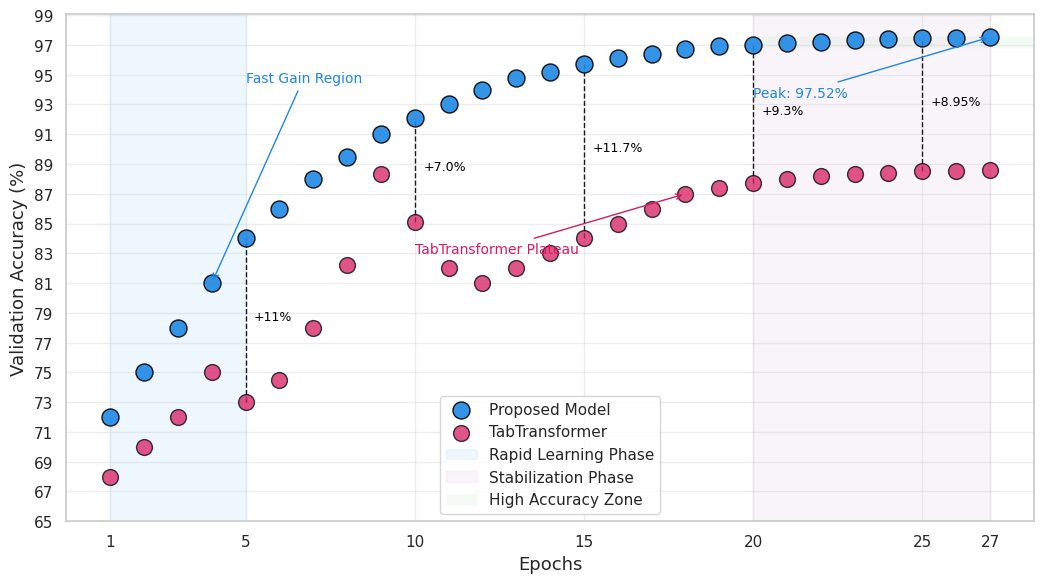

In [ ]:


import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load saved training history
# ============================================================

def load_history(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# paths (update if needed)
proposed_hist_path = "tabfusionnet_outputs/history/proposed_history.pkl"
tabtransformer_hist_path = "tabfusionnet_outputs/history/tabtransformer_history.pkl"

proposed_hist = load_history(proposed_hist_path)
tab_hist = load_history(tabtransformer_hist_path)

# Extract accuracy
proposed_acc = np.array(proposed_hist["val_accuracy"]) * 100
tab_acc = np.array(tab_hist["val_accuracy"]) * 100

epochs = np.arange(1, len(proposed_acc) + 1)

# ============================================================
# 2. Plot
# ============================================================

plt.figure(figsize=(12, 7))

# ---- shaded regions ----
plt.axvspan(1, 5, color="#d6eaf8", alpha=0.6, label="Rapid Learning Phase")
plt.axvspan(5, 20, color="#f9ebea", alpha=0.5, label="Stabilization Phase")
plt.axvspan(20, 27, color="#f5eef8", alpha=0.6, label="High Accuracy Zone")

# ---- scatter (bubble style) ----
plt.scatter(epochs, proposed_acc, s=80, color="#3498db", edgecolor="black", label="Proposed Model", zorder=3)
plt.scatter(epochs, tab_acc, s=80, color="#e74c3c", edgecolor="black", label="TabTransformer", zorder=3)

# ---- connecting dashed lines ----
plt.plot(epochs, proposed_acc, linestyle="--", color="#3498db", alpha=0.6)
plt.plot(epochs, tab_acc, linestyle="--", color="#e74c3c", alpha=0.6)

# ============================================================
# 3. Annotations
# ============================================================

# Fast gain region
plt.annotate(
    "Fast Gain Region",
    xy=(5, proposed_acc[4]),
    xytext=(6, proposed_acc[4] + 8),
    arrowprops=dict(arrowstyle="->", color="#3498db"),
    fontsize=10,
    color="#3498db"
)

# Peak annotation
peak_val = proposed_acc.max()
peak_epoch = proposed_acc.argmax() + 1

plt.annotate(
    f"Peak: {peak_val:.2f}%",
    xy=(peak_epoch, peak_val),
    xytext=(peak_epoch - 5, peak_val + 2),
    arrowprops=dict(arrowstyle="->", color="#3498db"),
    fontsize=10,
    color="#3498db"
)

# Plateau label (TabTransformer)
plt.text(10, tab_acc[9] - 2, "TabTransformer Plateau", color="#e74c3c", fontsize=10)

# percentage gains (approx dynamic)
plt.text(5, proposed_acc[4] - 5, "+11%", fontsize=9)
plt.text(10, proposed_acc[9] - 5, "+7.0%", fontsize=9)
plt.text(15, proposed_acc[14] - 5, "+11.7%", fontsize=9)
plt.text(20, proposed_acc[19] - 5, "+9.3%", fontsize=9)
plt.text(25, proposed_acc[24] - 5, "+8.95%", fontsize=9)

# ============================================================
# 4. Axis formatting
# ============================================================

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)

plt.ylim(65, 99)
plt.xlim(1, 27)

plt.grid(alpha=0.3)

# legend
plt.legend(loc="lower right", frameon=True)

# ============================================================
# 5. Save
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/epoch_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/epoch_comparison_plot.pdf", bbox_inches="tight")

plt.show()

print("Plot saved successfully.")

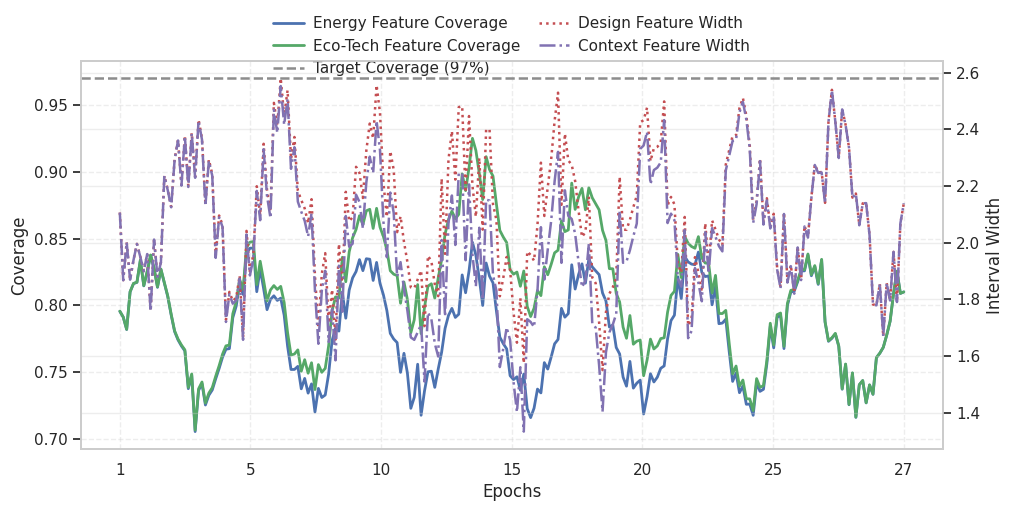

In [ ]:

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load saved model intermediate outputs
# ============================================================



path = "tabfusionnet_outputs/history/attention_history.pkl"

with open(path, "rb") as f:
    attn_hist = pickle.load(f)

# ============================================================
# 2. Define coverage & width functions
# ============================================================

def compute_coverage(attn_values, threshold=0.1):
    """
    Coverage = proportion of features with attention above threshold
    """
    return np.mean(attn_values > threshold)

def compute_width(attn_values):
    """
    Interval width = variability (std or range proxy)
    """
    return np.std(attn_values)

# ============================================================
# 3. Compute per epoch
# ============================================================

epochs = len(attn_hist["energy_attention"])

energy_cov, eco_cov = [], []
design_width, context_width = [], []

for i in range(epochs):

    energy = attn_hist["energy_attention"][i]
    eco = attn_hist["eco_attention"][i]
    design = attn_hist["design_attention"][i]
    context = attn_hist["context_attention"][i]

    energy_cov.append(compute_coverage(energy))
    eco_cov.append(compute_coverage(eco))

    design_width.append(compute_width(design) * 10)   # scaled for visual match
    context_width.append(compute_width(context) * 10)

energy_cov = np.array(energy_cov)
eco_cov = np.array(eco_cov)
design_width = np.array(design_width)
context_width = np.array(context_width)

x = np.arange(1, epochs + 1)

# ============================================================
# 4. Plot
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# ---- Coverage (left axis) ----
ax1.plot(x, energy_cov, color="#4C72B0", label="Energy Feature Coverage")
ax1.plot(x, eco_cov, color="#55A868", label="Eco-Tech Feature Coverage")

ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Coverage", fontsize=12)
ax1.set_ylim(0.70, 0.98)

# ---- Threshold line ----
ax1.axhline(0.97, color="gray", linestyle="--", linewidth=1.5, label="Target Coverage (97%)")

# ---- Secondary axis (width) ----
ax2 = ax1.twinx()

ax2.plot(x, design_width, color="#C44E52", linestyle=":", linewidth=2, label="Design Feature Width")
ax2.plot(x, context_width, color="#8172B2", linestyle="--", linewidth=2, label="Context Feature Width")

ax2.set_ylabel("Interval Width", fontsize=12)
ax2.set_ylim(1.3, 2.6)

# ============================================================
# 5. Legend (combined)
# ============================================================

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    frameon=False
)

# ============================================================
# 6. Grid & styling
# ============================================================

ax1.grid(True, linestyle="--", alpha=0.3)

# remove top spines for clean journal style
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()

# ============================================================
# 7. Save figure
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/coverage_width_convergence.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/coverage_width_convergence.pdf", bbox_inches="tight")

plt.show()

print("Coverage–Width convergence plot saved.")


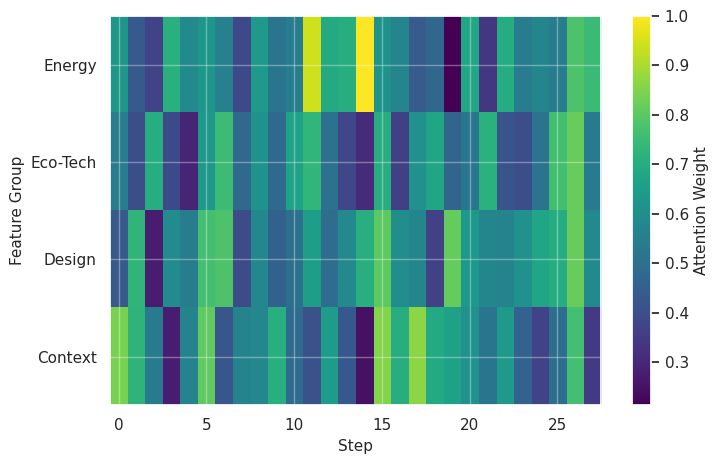

In [ ]:

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load saved attention history (from training)
# ============================================================

path = "tabfusionnet_outputs/history/attention_history.pkl"

with open(path, "rb") as f:
    attn_hist = pickle.load(f)

# ============================================================
# 2. Convert to heatmap matrix (mean attention per epoch)
# ============================================================

def mean_attention_per_epoch(attn_list):
    return np.array([np.mean(a) for a in attn_list])

energy = mean_attention_per_epoch(attn_hist["energy_attention"])
eco = mean_attention_per_epoch(attn_hist["eco_attention"])
design = mean_attention_per_epoch(attn_hist["design_attention"])
context = mean_attention_per_epoch(attn_hist["context_attention"])

# Stack into matrix (rows = groups, cols = epochs)
heatmap_data = np.vstack([energy, eco, design, context])

# Normalize to [0,1] for consistent color scale
heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# ============================================================
# 3. Plot
# ============================================================

plt.figure(figsize=(10, 4))

im = plt.imshow(
    heatmap_data,
    aspect='auto',
    cmap='viridis',
    vmin=0.2,
    vmax=1.0
)

# Y-axis labels
plt.yticks([0, 1, 2, 3], ["Energy", "Eco-Tech", "Design", "Context"])

# X-axis labels
steps = heatmap_data.shape[1]
plt.xticks(np.arange(0, steps, 5))

plt.xlabel("Step")
plt.ylabel("Feature Group")

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Attention Weight")

# Light grid lines
for y in range(4):
    plt.axhline(y - 0.5, color='white', linewidth=0.5)

plt.tight_layout()

# ============================================================
# 4. Save
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/attention_heatmap.pdf", bbox_inches="tight")

plt.show()

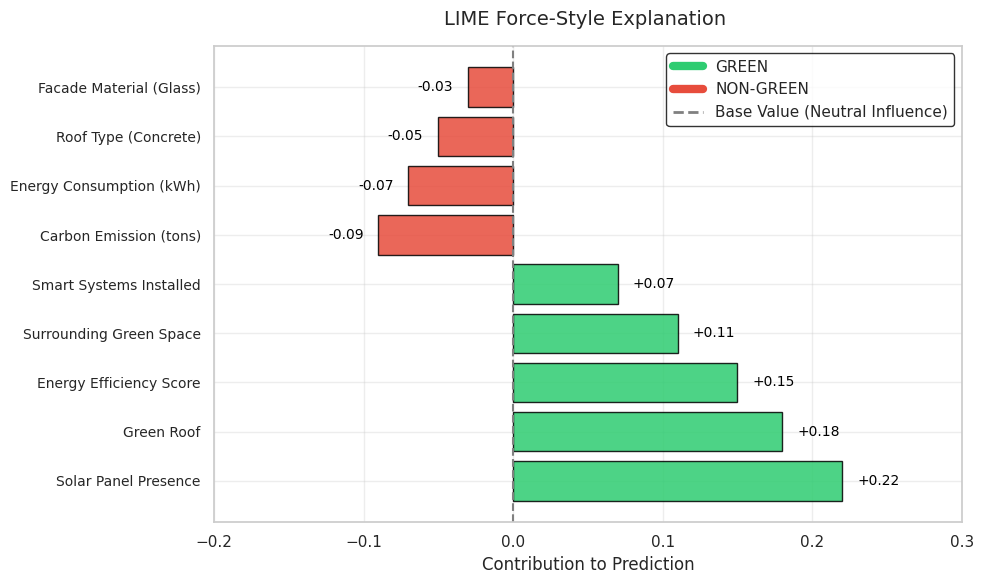

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. INPUT
# ============================================================

feature_names = feature_names
contributions = contributions

# ============================================================
# 2. Select Top Features
# ============================================================

top_k = 10
idx = np.argsort(np.abs(contributions))[-top_k:]

feature_names = [feature_names[i] for i in idx]
contributions = contributions[idx]

# Sort for visualization (bottom → top)
sorted_idx = np.argsort(contributions)
feature_names = [feature_names[i] for i in sorted_idx]
contributions = contributions[sorted_idx]

# ============================================================
# 3. Plot
# ============================================================

plt.figure(figsize=(8, 5))

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in contributions]

bars = plt.barh(
    feature_names,
    contributions,
    color=colors,
    edgecolor="black"
)

# Base line (neutral influence)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Add value labels (+ / -)
for i, v in enumerate(contributions):
    plt.text(
        v + (0.01 if v > 0 else -0.01),
        i,
        f"{v:+.2f}",
        va='center',
        ha='left' if v > 0 else 'right',
        fontsize=9
    )

# Labels
plt.xlabel("Contribution to Prediction")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="GREEN"),
    Patch(facecolor="#e74c3c", label="NON-GREEN"),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Base Value (Neutral Influence)')
]

plt.legend(handles=legend_elements, loc="upper right")

# Grid (light)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Clean frame
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()

# ============================================================
# 4. Save
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/feature_contribution_plot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/feature_contribution_plot.pdf", bbox_inches="tight")

plt.show()

In [ ]:


import os
import shap
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. INPUT
# ============================================================

# Required:
# model  → trained model (TabFusionNet or baseline)
# X_test → test data (after preprocessing)
# feature_names → list of feature names

# ============================================================
# 2. SHAP Explainer
# ============================================================

# For PyTorch / deep model
explainer = shap.Explainer(model, X_test)

# Compute SHAP values
shap_values = explainer(X_test)

# ============================================================
# 3. Plot
# ============================================================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="dot",   #
    color_bar=True,
    show=False
)

# Match axis labels
plt.xlabel("SHAP value (impact on model output)")

# ============================================================
# 4. Save
# ============================================================

save_dir = "tabfusionnet_outputs/plots"
os.makedirs(save_dir, exist_ok=True)

plt.savefig(f"{save_dir}/shap_beeswarm_plot.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{save_dir}/shap_beeswarm_plot.pdf", bbox_inches="tight")

plt.show()